In [12]:
import polars as pl
import elfen

df = pl.read_csv("english_sentance_elfen_1000_named.csv")

print(df.shape)
print(df.columns)
print(df.head())
print("Missing text:", df["text"].null_count())
print("Unique sentences:", df["text"].n_unique())

c:\Users\kanch\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(1000, 2)
['id', 'text']
shape: (5, 2)
┌─────┬─────────────────────────────────┐
│ id  ┆ text                            │
│ --- ┆ ---                             │
│ i64 ┆ str                             │
╞═════╪═════════════════════════════════╡
│ 1   ┆ I didn't know what to wear to … │
│ 2   ┆ There used to be a big cherry … │
│ 3   ┆ Sometimes, books and movies ma… │
│ 4   ┆ My bandaid wasn't sticky anymo… │
│ 5   ┆ He only had one drink but he's… │
└─────┴─────────────────────────────────┘
Missing text: 0
Unique sentences: 1000


In [13]:
import elfen

extractor = elfen.Extractor(
    data=df,
    language="en",
    text_column="text"
)

print("Extractor created successfully!")

Extractor created successfully!


In [14]:
extractor.extract("ttr")

print("TTR extraction successful!")
print("Shape:", extractor.data.shape)
print("TTR columns:")
print([col for col in extractor.data.columns if "ttr" in col.lower()])

TTR extraction successful!
Shape: (1000, 6)
TTR columns:
['ttr']


In [15]:
extractor.extract_feature_group("readability")

print("Readability extraction successful!")
print(extractor.data.shape)
print(extractor.data.columns)

Readability extraction successful!
(1000, 20)
['id', 'text', 'nlp', 'n_tokens', 'n_types', 'ttr', 'n_sentences', 'n_syllables', 'flesch_reading_ease', 'flesch_kincaid_grade', 'n_polysyllables', 'smog', 'n_characters', 'ari', 'cli', 'gunning_fog', 'n_long_words', 'lix', 'rix', 'n_monosyllables']


In [16]:
print(extractor.data.select([
    "id",
    "text",
    "n_tokens",
    "n_sentences",
    "n_syllables",
    "flesch_reading_ease",
    "flesch_kincaid_grade",
    "n_polysyllables",
    "smog",
    "n_characters",
    "ari",
    "cli",
    "gunning_fog",
    "n_long_words",
    "lix",
    "rix",
    "n_monosyllables"
]).head(10))

shape: (10, 17)
┌─────┬───────────────┬──────────┬─────────────┬───┬──────────────┬───────────┬─────┬──────────────┐
│ id  ┆ text          ┆ n_tokens ┆ n_sentences ┆ … ┆ n_long_words ┆ lix       ┆ rix ┆ n_monosyllab │
│ --- ┆ ---           ┆ ---      ┆ ---         ┆   ┆ ---          ┆ ---       ┆ --- ┆ les          │
│ i64 ┆ str           ┆ u16      ┆ u16         ┆   ┆ u16          ┆ f64       ┆ f64 ┆ ---          │
│     ┆               ┆          ┆             ┆   ┆              ┆           ┆     ┆ u16          │
╞═════╪═══════════════╪══════════╪═════════════╪═══╪══════════════╪═══════════╪═════╪══════════════╡
│ 1   ┆ I didn't know ┆ 14       ┆ 1           ┆ … ┆ 2            ┆ 28.285714 ┆ 2.0 ┆ 10           │
│     ┆ what to wear  ┆          ┆             ┆   ┆              ┆           ┆     ┆              │
│     ┆ to …          ┆          ┆             ┆   ┆              ┆           ┆     ┆              │
│ 2   ┆ There used to ┆ 12       ┆ 1           ┆ … ┆ 2            ┆ 28.6666

In [17]:
print(extractor.data.select([
    "flesch_reading_ease",
    "flesch_kincaid_grade",
    "smog",
    "ari",
    "cli",
    "gunning_fog",
    "lix",
    "rix"
]).describe())

shape: (9, 9)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ statistic ┆ flesch_re ┆ flesch_ki ┆ smog      ┆ … ┆ cli       ┆ gunning_f ┆ lix       ┆ rix      │
│ ---       ┆ ading_eas ┆ ncaid_gra ┆ ---       ┆   ┆ ---       ┆ og        ┆ ---       ┆ ---      │
│ str       ┆ e         ┆ de        ┆ f64       ┆   ┆ f64       ┆ ---       ┆ f64       ┆ f64      │
│           ┆ ---       ┆ ---       ┆           ┆   ┆           ┆ f64       ┆           ┆          │
│           ┆ f64       ┆ f64       ┆           ┆   ┆           ┆           ┆           ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ count     ┆ 1000.0    ┆ 1000.0    ┆ 1000.0    ┆ … ┆ 1000.0    ┆ 1000.0    ┆ 1000.0    ┆ 1000.0   │
│ null_coun ┆ 0.0       ┆ 0.0       ┆ 0.0       ┆ … ┆ 0.0       ┆ 0.0       ┆ 0.0       ┆ 0.0      │
│ t         ┆           ┆           ┆           ┆   ┆           ┆           ┆

In [18]:
print(extractor.data.select([
    "id",
    "text",

    "flesch_reading_ease",
    "flesch_kincaid_grade",
]).head(10))

shape: (10, 4)
┌─────┬─────────────────────────────────┬─────────────────────┬──────────────────────┐
│ id  ┆ text                            ┆ flesch_reading_ease ┆ flesch_kincaid_grade │
│ --- ┆ ---                             ┆ ---                 ┆ ---                  │
│ i64 ┆ str                             ┆ f64                 ┆ f64                  │
╞═════╪═════════════════════════════════╪═════════════════════╪══════════════════════╡
│ 1   ┆ I didn't know what to wear to … ┆ -907.175            ┆ 143.27               │
│ 2   ┆ There used to be a big cherry … ┆ -905.145            ┆ 142.49               │
│ 3   ┆ Sometimes, books and movies ma… ┆ -907.175            ┆ 143.27               │
│ 4   ┆ My bandaid wasn't sticky anymo… ┆ -435.785            ┆ 76.03                │
│ 5   ┆ He only had one drink but he's… ┆ -904.13             ┆ 142.1                │
│ 6   ┆ In Hong Kong, everyone lives s… ┆ -732.9              ┆ 117.72               │
│ 7   ┆ Her parents had been

In [19]:
print(extractor.data.select([
    "n_tokens",
    "n_sentences",
    "n_syllables",
    "n_polysyllables",
    "n_monosyllables",
    "flesch_reading_ease"
]).head(20))

shape: (20, 6)
┌──────────┬─────────────┬─────────────┬─────────────────┬─────────────────┬─────────────────────┐
│ n_tokens ┆ n_sentences ┆ n_syllables ┆ n_polysyllables ┆ n_monosyllables ┆ flesch_reading_ease │
│ ---      ┆ ---         ┆ ---         ┆ ---             ┆ ---             ┆ ---                 │
│ u16      ┆ u16         ┆ u16         ┆ u16             ┆ u16             ┆ f64                 │
╞══════════╪═════════════╪═════════════╪═════════════════╪═════════════════╪═════════════════════╡
│ 14       ┆ 1           ┆ 13          ┆ 1               ┆ 10              ┆ -907.175            │
│ 12       ┆ 1           ┆ 13          ┆ 0               ┆ 9               ┆ -905.145            │
│ 14       ┆ 1           ┆ 13          ┆ 0               ┆ 9               ┆ -907.175            │
│ 16       ┆ 2           ┆ 15          ┆ 0               ┆ 13              ┆ -435.785            │
│ 11       ┆ 1           ┆ 13          ┆ 1               ┆ 6               ┆ -904.13          

In [20]:
row = extractor.data.row(0, named=True)

print("Tokens:", row["n_tokens"])
print("Sentences:", row["n_sentences"])
print("Syllables:", row["n_syllables"])
print("ELFEN Flesch:", row["flesch_reading_ease"])

manual = (
    206.835
    - 1.015 * (row["n_tokens"] / row["n_sentences"])
    - 84.6 * (row["n_syllables"] / row["n_tokens"])
)

print("Manual Flesch:", manual)

Tokens: 14
Sentences: 1
Syllables: 13
ELFEN Flesch: -907.175
Manual Flesch: 114.06785714285715


In [21]:
import importlib.metadata

print("ELFEN version:", importlib.metadata.version("elfen"))

ELFEN version: 1.3.1


In [22]:
import inspect
from elfen.readability import get_flesch_reading_ease

print(inspect.getsource(get_flesch_reading_ease))

def get_flesch_reading_ease(data: pl.DataFrame,
                            backbone: str = 'spacy',
                            **kwargs: dict[str, str],
                            ) -> pl.DataFrame:
    """
    Calculates the Flesch Reading Ease score of a text.

    Args:
        data (pl.DataFrame): APolars DataFrame containing the text data.
        backbone (str):
            The NLP library used to process the text data.
            Either 'spacy' or 'stanza'.
            Not supported for Stanza backbone.

    Returns:
        data (pl.DataFrame):
            A Polars DataFrame containing the Flesch Reading Ease score
            of the text data. The Flesch Reading Ease score is stored
            in a new column named 'flesch_reading_ease'.
    """
    if 'n_tokens' not in data.columns:
        data = get_num_tokens(data, backbone=backbone)
    if 'n_sentences' not in data.columns:
        data = get_num_sentences(data, backbone=backbone)
    if 'n_syllables' not in data.col

Example of the Observed Readability Output

For the first sentence in the dataset, ELFEN 1.3.1 produced:

| ID | Text | Flesch Reading Ease | Flesch-Kincaid Grade |
|---:|---|---:|---:|
| 1 | I didn't know what to wear to ... | -907.175 | 143.27 |

The Flesch Reading Ease value is extremely negative and the Flesch-Kincaid Grade value is unusually high for this short sentence.

Further formula validation showed that the Flesch Reading Ease value is directly reproduced by the formula implemented in the installed ELFEN 1.3.1 package. The discrepancy arises because the implementation uses `n_syllables / n_sentences` for the syllable component rather than `n_syllables / n_tokens`.

This observation is recorded as an implementation discrepancy for ELFEN 1.3.1 and is retained as part of the baseline experiment.

In [23]:
# Extract surface-level linguistic features

extractor.extract_feature_group("surface")

print("Surface feature extraction successful!")
print("Shape:", extractor.data.shape)

print("Surface feature columns:")
print(extractor.data.columns)

Surface feature extraction successful!
Shape: (1000, 24)
Surface feature columns:
['id', 'text', 'nlp', 'n_tokens', 'n_types', 'ttr', 'n_sentences', 'n_syllables', 'flesch_reading_ease', 'flesch_kincaid_grade', 'n_polysyllables', 'smog', 'n_characters', 'ari', 'cli', 'gunning_fog', 'n_long_words', 'lix', 'rix', 'n_monosyllables', 'raw_sequence_length', 'n_lemmas', 'avg_word_length', 'tokens_per_sentence']


In [24]:
print(extractor.data.select([
    "id",
    "text",
    "raw_sequence_length",
    "n_lemmas",
    "avg_word_length",
    "tokens_per_sentence"
]).head(10))

shape: (10, 6)
┌─────┬─────────────────────┬────────────────────┬──────────┬─────────────────┬────────────────────┐
│ id  ┆ text                ┆ raw_sequence_lengt ┆ n_lemmas ┆ avg_word_length ┆ tokens_per_sentenc │
│ --- ┆ ---                 ┆ h                  ┆ ---      ┆ ---             ┆ e                  │
│ i64 ┆ str                 ┆ ---                ┆ u16      ┆ f64             ┆ ---                │
│     ┆                     ┆ u16                ┆          ┆                 ┆ f64                │
╞═════╪═════════════════════╪════════════════════╪══════════╪═════════════════╪════════════════════╡
│ 1   ┆ I didn't know what  ┆ 55                 ┆ 13       ┆ 3.214286        ┆ 14.0               │
│     ┆ to wear to …        ┆                    ┆          ┆                 ┆                    │
│ 2   ┆ There used to be a  ┆ 51                 ┆ 12       ┆ 3.416667        ┆ 12.0               │
│     ┆ big cherry …        ┆                    ┆          ┆               

In [25]:
print(extractor.data.select([
    "raw_sequence_length",
    "n_lemmas",
    "avg_word_length",
    "tokens_per_sentence"
]).null_count())

shape: (1, 4)
┌─────────────────────┬──────────┬─────────────────┬─────────────────────┐
│ raw_sequence_length ┆ n_lemmas ┆ avg_word_length ┆ tokens_per_sentence │
│ ---                 ┆ ---      ┆ ---             ┆ ---                 │
│ u32                 ┆ u32      ┆ u32             ┆ u32                 │
╞═════════════════════╪══════════╪═════════════════╪═════════════════════╡
│ 0                   ┆ 0        ┆ 0               ┆ 0                   │
└─────────────────────┴──────────┴─────────────────┴─────────────────────┘


In [26]:
# Extract dependency-based linguistic features

extractor.extract_feature_group("dependency")

print("Dependency feature extraction successful!")
print("Shape:", extractor.data.shape)

print("Dependency feature columns:")
print(extractor.data.columns)

Dependency feature extraction successful!
Shape: (1000, 74)
Dependency feature columns:
['id', 'text', 'nlp', 'n_tokens', 'n_types', 'ttr', 'n_sentences', 'n_syllables', 'flesch_reading_ease', 'flesch_kincaid_grade', 'n_polysyllables', 'smog', 'n_characters', 'ari', 'cli', 'gunning_fog', 'n_long_words', 'lix', 'rix', 'n_monosyllables', 'raw_sequence_length', 'n_lemmas', 'avg_word_length', 'tokens_per_sentence', 'tree_width', 'tree_depth', 'tree_branching', 'ramification_factor', 'n_noun_chunks', 'n_dependency_acl', 'n_dependency_acomp', 'n_dependency_advcl', 'n_dependency_advmod', 'n_dependency_agent', 'n_dependency_amod', 'n_dependency_appos', 'n_dependency_attr', 'n_dependency_aux', 'n_dependency_auxpass', 'n_dependency_case', 'n_dependency_cc', 'n_dependency_ccomp', 'n_dependency_compound', 'n_dependency_conj', 'n_dependency_csubj', 'n_dependency_csubjpass', 'n_dependency_dative', 'n_dependency_dep', 'n_dependency_det', 'n_dependency_dobj', 'n_dependency_expl', 'n_dependency_intj', 

In [27]:
dependency_columns = [
    col for col in extractor.data.columns
    if col.startswith("tree_")
    or col in [
        "ramification_factor",
        "n_noun_chunks"
    ]
    or col.startswith("n_dependency_")
]

print("Number of dependency features:", len(dependency_columns))

print(
    extractor.data.select(dependency_columns).null_count()
)

Number of dependency features: 50
shape: (1, 50)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ tree_widt ┆ tree_dept ┆ tree_bran ┆ ramificat ┆ … ┆ n_depende ┆ n_depende ┆ n_depende ┆ n_depend │
│ h         ┆ h         ┆ ching     ┆ ion_facto ┆   ┆ ncy_quant ┆ ncy_relcl ┆ ncy_root  ┆ ency_xco │
│ ---       ┆ ---       ┆ ---       ┆ r         ┆   ┆ mod       ┆ ---       ┆ ---       ┆ mp       │
│ u32       ┆ u32       ┆ u32       ┆ ---       ┆   ┆ ---       ┆ u32       ┆ u32       ┆ ---      │
│           ┆           ┆           ┆ u32       ┆   ┆ u32       ┆           ┆           ┆ u32      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 0         ┆ 0         ┆ 0         ┆ 0         ┆ … ┆ 0         ┆ 0         ┆ 0         ┆ 0        │
└───────────┴───────────┴───────────┴───────────┴───┴───────────┴───────────┴───────────┴──────────┘


In [28]:
print(extractor.data.select([
    "id",
    "text",
    "tree_width",
    "tree_depth",
    "tree_branching",
    "ramification_factor",
    "n_noun_chunks",
    "n_dependency_nsubj",
    "n_dependency_dobj",
    "n_dependency_root"
]).head(10))

shape: (10, 10)
┌─────┬────────────┬────────────┬────────────┬───┬────────────┬────────────┬───────────┬───────────┐
│ id  ┆ text       ┆ tree_width ┆ tree_depth ┆ … ┆ n_noun_chu ┆ n_dependen ┆ n_depende ┆ n_depende │
│ --- ┆ ---        ┆ ---        ┆ ---        ┆   ┆ nks        ┆ cy_nsubj   ┆ ncy_dobj  ┆ ncy_root  │
│ i64 ┆ str        ┆ u16        ┆ f64        ┆   ┆ ---        ┆ ---        ┆ ---       ┆ ---       │
│     ┆            ┆            ┆            ┆   ┆ u16        ┆ u16        ┆ u16       ┆ u16       │
╞═════╪════════════╪════════════╪════════════╪═══╪════════════╪════════════╪═══════════╪═══════════╡
│ 1   ┆ I didn't   ┆ 5          ┆ 5.0        ┆ … ┆ 3          ┆ 1          ┆ 1         ┆ 0         │
│     ┆ know what  ┆            ┆            ┆   ┆            ┆            ┆           ┆           │
│     ┆ to wear to ┆            ┆            ┆   ┆            ┆            ┆           ┆           │
│     ┆ …          ┆            ┆            ┆   ┆            ┆            

In [29]:
# Extract morphology-based linguistic features

extractor.extract_feature_group("Morphology")

print("Morphology feature extraction successful!")
print("Shape:", extractor.data.shape)

print("Morphology feature columns:")
print(extractor.data.columns)

Feature group Morphology not found. Check spelling.
Morphology feature extraction successful!
Shape: (1000, 74)
Morphology feature columns:
['id', 'text', 'nlp', 'n_tokens', 'n_types', 'ttr', 'n_sentences', 'n_syllables', 'flesch_reading_ease', 'flesch_kincaid_grade', 'n_polysyllables', 'smog', 'n_characters', 'ari', 'cli', 'gunning_fog', 'n_long_words', 'lix', 'rix', 'n_monosyllables', 'raw_sequence_length', 'n_lemmas', 'avg_word_length', 'tokens_per_sentence', 'tree_width', 'tree_depth', 'tree_branching', 'ramification_factor', 'n_noun_chunks', 'n_dependency_acl', 'n_dependency_acomp', 'n_dependency_advcl', 'n_dependency_advmod', 'n_dependency_agent', 'n_dependency_amod', 'n_dependency_appos', 'n_dependency_attr', 'n_dependency_aux', 'n_dependency_auxpass', 'n_dependency_case', 'n_dependency_cc', 'n_dependency_ccomp', 'n_dependency_compound', 'n_dependency_conj', 'n_dependency_csubj', 'n_dependency_csubjpass', 'n_dependency_dative', 'n_dependency_dep', 'n_dependency_det', 'n_dependen

In [30]:
print(dir(extractor))

['_Extractor__apply_function', '_Extractor__cleanup_cols', '_Extractor__gather_resource_from_featurename', '_Extractor__load_lexicon_from_featurename', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', 'basic_features', 'config', 'data', 'extract', 'extract_feature_group', 'extract_features', 'get_corpus_frequencies', 'get_data', 'get_feature_names', 'helper_cols', 'initial_cols', 'normalize', 'ratio_features', 'ratio_normalize', 'remove_constant_cols', 'rescale', 'token_normalize', 'write_csv']


In [31]:
feature_names = extractor.get_feature_names()

print("Number of available features:", len(feature_names))
print(feature_names)

Number of available features: 71
['n_dependency_punct', 'raw_sequence_length', 'n_dependency_amod', 'n_dependency_nsubj', 'n_polysyllables', 'n_dependency_relcl', 'n_dependency_nsubjpass', 'rix', 'tree_branching', 'n_dependency_intj', 'n_dependency_pobj', 'ttr', 'n_dependency_oprd', 'ari', 'n_monosyllables', 'n_dependency_case', 'n_dependency_appos', 'n_dependency_meta', 'n_dependency_preconj', 'cli', 'n_dependency_prt', 'lix', 'n_dependency_det', 'n_dependency_nounmod', 'n_dependency_npmod', 'n_dependency_conj', 'n_dependency_pcomp', 'n_dependency_agent', 'n_noun_chunks', 'n_dependency_attr', 'n_dependency_mark', 'n_dependency_aux', 'n_dependency_dative', 'n_dependency_acl', 'n_dependency_dobj', 'n_dependency_dep', 'flesch_kincaid_grade', 'n_dependency_predet', 'n_dependency_expl', 'n_lemmas', 'ramification_factor', 'n_dependency_ccomp', 'n_dependency_quantmod', 'n_dependency_root', 'n_sentences', 'n_dependency_advmod', 'smog', 'flesch_reading_ease', 'n_dependency_csubj', 'gunning_fog

In [32]:
morphology_features = [
    feature for feature in feature_names
    if any(word in feature.lower() for word in [
        "morph", "pos", "verb", "noun", "adj", "adp", "det"
    ])
]

print("Possible morphology-related features:")
print(morphology_features)

Possible morphology-related features:
['n_dependency_appos', 'n_dependency_det', 'n_dependency_nounmod', 'n_noun_chunks', 'n_dependency_predet', 'n_dependency_poss']


In [33]:
extractor.extract_feature_group("morphology")

Feature group morphology not found. Check spelling.


In [34]:
print(extractor.config)

{'backbone': 'spacy', 'language': 'en', 'model': 'en_core_web_sm', 'text_column': 'text', 'max_length': 1000000, 'remove_constant_cols': False, 'features': {'surface': ['raw_sequence_length', 'n_tokens', 'n_sentences', 'n_tokens_per_sentence', 'n_characters', 'avg_word_length', 'n_types', 'n_long_words', 'n_lemmas'], 'morphology': ['n_per_morph_feature'], 'dependency': ['tree_width', 'tree_depth', 'tree_branching', 'n_noun_chunks', 'n_per_dependency_type'], 'emotion': ['sentiment_score', 'n_negative_sentiment', 'n_positive_sentiment', 'avg_valence', 'n_low_valence', 'n_high_valence', 'avg_arousal', 'n_low_arousal', 'n_high_arousal', 'avg_dominance', 'n_low_dominance', 'n_high_dominance', 'avg_emotion_intensity', 'n_low_intensity', 'n_high_intensity'], 'information': ['compressibility', 'entropy'], 'lexical_richness': ['lemma_token_ratio', 'ttr', 'rttr', 'cttr', 'herdan_c', 'summer_index', 'dugast_u', 'maas_index', 'lexical_density', 'n_hapax_legomena', 'n_global_token_hapax_legomena', 

In [35]:
# Extract the morphology feature directly

extractor.extract("n_per_morph_feature")

print("Morphology feature extraction attempted.")
print("Shape:", extractor.data.shape)

print("Morphology columns:")
print([
    col for col in extractor.data.columns
    if "morph" in col.lower()
])

Morphology feature extraction attempted.
Shape: (1000, 872)
Morphology columns:
[]


In [36]:
print(
    extractor.data.select([
        "id",
        "text",
        "n_per_morph_feature"
    ]).head(10)
)

ColumnNotFoundError: unable to find column "n_per_morph_feature"; valid columns: ["id", "text", "nlp", "n_tokens", "n_types", "ttr", "n_sentences", "n_syllables", "flesch_reading_ease", "flesch_kincaid_grade", "n_polysyllables", "smog", "n_characters", "ari", "cli", "gunning_fog", "n_long_words", "lix", "rix", "n_monosyllables", "raw_sequence_length", "n_lemmas", "avg_word_length", "tokens_per_sentence", "tree_width", "tree_depth", "tree_branching", "ramification_factor", "n_noun_chunks", "n_dependency_acl", "n_dependency_acomp", "n_dependency_advcl", "n_dependency_advmod", "n_dependency_agent", "n_dependency_amod", "n_dependency_appos", "n_dependency_attr", "n_dependency_aux", "n_dependency_auxpass", "n_dependency_case", "n_dependency_cc", "n_dependency_ccomp", "n_dependency_compound", "n_dependency_conj", "n_dependency_csubj", "n_dependency_csubjpass", "n_dependency_dative", "n_dependency_dep", "n_dependency_det", "n_dependency_dobj", "n_dependency_expl", "n_dependency_intj", "n_depe

In [ ]:
print("Current shape:", extractor.data.shape)

morphology_columns = [
    col for col in extractor.data.columns
    if col.startswith("n_")
    and not col.startswith("n_dependency_")
    and col not in [
        "n_tokens",
        "n_types",
        "n_sentences",
        "n_syllables",
        "n_polysyllables",
        "n_monosyllables",
        "n_characters",
        "n_long_words",
        "n_lemmas",
        "n_noun_chunks"
    ]
]

print("Number of morphology-related columns:", len(morphology_columns))

Current shape: (1000, 872)
Number of morphology-related columns: 798


In [ ]:
print("First 20 morphology columns:")
print(morphology_columns[:20])

First 20 morphology columns:
['n_VERB_VerbForm_Conf', 'n_VERB_VerbForm_Fin', 'n_VERB_VerbForm_Gdv', 'n_VERB_VerbForm_Ger', 'n_VERB_VerbForm_Inf', 'n_VERB_VerbForm_Part', 'n_VERB_VerbForm_Sup', 'n_VERB_VerbForm_Vnoun', 'n_VERB_Mood_Adm', 'n_VERB_Mood_Cnd', 'n_VERB_Mood_Des', 'n_VERB_Mood_Imp', 'n_VERB_Mood_Ind', 'n_VERB_Mood_Irr', 'n_VERB_Mood_Jus', 'n_VERB_Mood_Nec', 'n_VERB_Mood_Opt', 'n_VERB_Mood_Pot', 'n_VERB_Mood_Prp', 'n_VERB_Mood_Qot']


In [ ]:
print(
    extractor.data.select(morphology_columns).null_count()
)

shape: (1, 798)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ n_VERB_Ve ┆ n_VERB_Ve ┆ n_VERB_Ve ┆ n_VERB_Ve ┆ … ┆ n_ADP_Adp ┆ n_ADP_Adp ┆ n_ADP_Adp ┆ n_ADP_Ad │
│ rbForm_Co ┆ rbForm_Fi ┆ rbForm_Gd ┆ rbForm_Ge ┆   ┆ Type_Prep ┆ Type_Post ┆ Type_Circ ┆ pType_Vo │
│ nf        ┆ n         ┆ v         ┆ r         ┆   ┆ ---       ┆ ---       ┆ ---       ┆ c        │
│ ---       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ u32       ┆ u32       ┆ u32       ┆ ---      │
│ u32       ┆ u32       ┆ u32       ┆ u32       ┆   ┆           ┆           ┆           ┆ u32      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 0         ┆ 0         ┆ 0         ┆ 0         ┆ … ┆ 0         ┆ 0         ┆ 0         ┆ 0        │
└───────────┴───────────┴───────────┴───────────┴───┴───────────┴───────────┴───────────┴──────────┘


In [ ]:
morph_prefixes = (
    "n_VERB_",
    "n_NOUN_",
    "n_PRON_",
    "n_ADJ_",
    "n_DET_",
    "n_NUM_",
    "n_ADV_",
    "n_PROPN_",
    "n_AUX_",
    "n_Aux_",
    "n_PUNCT_",
    "n_CONJ_",
    "n_CCONJ_",
    "n_SCONJ_",
    "n_ADP_"
)

exact_morphology_columns = [
    col for col in extractor.data.columns
    if col.startswith(morph_prefixes)
]

print("Exact morphology columns:", len(exact_morphology_columns))
print("First 30:")
print(exact_morphology_columns[:30])

print("\nNull values:")
print(
    extractor.data
    .select(exact_morphology_columns)
    .null_count()
    .sum_horizontal()
    .item()
)

Exact morphology columns: 798
First 30:
['n_VERB_VerbForm_Conf', 'n_VERB_VerbForm_Fin', 'n_VERB_VerbForm_Gdv', 'n_VERB_VerbForm_Ger', 'n_VERB_VerbForm_Inf', 'n_VERB_VerbForm_Part', 'n_VERB_VerbForm_Sup', 'n_VERB_VerbForm_Vnoun', 'n_VERB_Mood_Adm', 'n_VERB_Mood_Cnd', 'n_VERB_Mood_Des', 'n_VERB_Mood_Imp', 'n_VERB_Mood_Ind', 'n_VERB_Mood_Irr', 'n_VERB_Mood_Jus', 'n_VERB_Mood_Nec', 'n_VERB_Mood_Opt', 'n_VERB_Mood_Pot', 'n_VERB_Mood_Prp', 'n_VERB_Mood_Qot', 'n_VERB_Mood_Sub', 'n_VERB_Tense_Fut', 'n_VERB_Tense_Imp', 'n_VERB_Tense_Past', 'n_VERB_Tense_Pres', 'n_VERB_Tense_Pqp', 'n_VERB_Aspect_Hab', 'n_VERB_Aspect_Imp', 'n_VERB_Aspect_Iter', 'n_VERB_Aspect_Perf']

Null values:
0


In [ ]:
print("Current shape:", extractor.data.shape)

pos_columns = [
    col for col in extractor.data.columns
    if col.startswith("n_per_pos")
    or col in ["n_lexical_tokens", "pos_variability"]
]

print("POS columns:")
print(pos_columns)

print("\nNumber of POS columns:", len(pos_columns))

print("\nMissing values:")
print(
    extractor.data
    .select(pos_columns)
    .null_count()
)

Current shape: (1000, 892)
POS columns:
['n_lexical_tokens', 'pos_variability']

Number of POS columns: 2

Missing values:
shape: (1, 2)
┌──────────────────┬─────────────────┐
│ n_lexical_tokens ┆ pos_variability │
│ ---              ┆ ---             │
│ u32              ┆ u32             │
╞══════════════════╪═════════════════╡
│ 0                ┆ 0               │
└──────────────────┴─────────────────┘


In [ ]:
id="5q5j5f"
print("Current columns:", len(extractor.data.columns))

print("\nLast 30 columns:")
print(extractor.data.columns[-30:])

Current columns: 892

Last 30 columns:
['n_CONJ_ConjType_Cmp', 'n_CONJ_ConjType_Oper', 'n_CCONJ_ConjType_Cmp', 'n_CCONJ_ConjType_Oper', 'n_SCONJ_ConjType_Cmp', 'n_SCONJ_ConjType_Oper', 'n_ADP_AdpType_Prep', 'n_ADP_AdpType_Post', 'n_ADP_AdpType_Circ', 'n_ADP_AdpType_Voc', 'n_lexical_tokens', 'pos_variability', 'n_adj', 'n_adp', 'n_adv', 'n_aux', 'n_conj', 'n_cconj', 'n_det', 'n_intj', 'n_noun', 'n_num', 'n_part', 'n_pron', 'n_propn', 'n_punct', 'n_sconj', 'n_sym', 'n_verb', 'n_x']


In [ ]:
pos_columns = [
    "n_lexical_tokens",
    "pos_variability",
    "n_adj",
    "n_adp",
    "n_adv",
    "n_aux",
    "n_conj",
    "n_cconj",
    "n_det",
    "n_intj",
    "n_noun",
    "n_num",
    "n_part",
    "n_pron",
    "n_propn",
    "n_punct",
    "n_sconj",
    "n_sym",
    "n_verb",
    "n_x"
]

print("Number of POS columns:", len(pos_columns))

nulls = extractor.data.select(pos_columns).null_count()

print("Total missing values across POS features:",
      nulls.sum_horizontal().item())

Number of POS columns: 20
Total missing values across POS features: 0


In [ ]:
lexical_result = extractor.extract_feature_group("lexical_richness")

print("Current shape:", extractor.data.shape)

print("Last 40 columns:")
print(extractor.data.columns[-40:])

Current shape: (1000, 918)
Last 40 columns:
['n_conj', 'n_cconj', 'n_det', 'n_intj', 'n_noun', 'n_num', 'n_part', 'n_pron', 'n_propn', 'n_punct', 'n_sconj', 'n_sym', 'n_verb', 'n_x', 'lemma_token_ratio', 'cttr', 'rttr', 'herdan_c', 'summer_index', 'dugast_u', 'maas_index', 'n_hapax_legomena', 'n_global_lemma_hapax_legomena', 'n_global_token_hapax_legomena', 'lexical_density', 'n_hapax_dislegomena', 'n_global_lemma_hapax_dislegomena', 'n_global_token_hapax_dislegomena', 'tokens', 'hdd', 'sichel_s', 'global_sichel_s', 'giroud_index', 'mtld', 'mattr', 'msttr', 'token_freqs', 'yule_k', 'simpsons_d', 'herdan_v']


In [ ]:
lexical_columns = [
    "lemma_token_ratio",
    "cttr",
    "rttr",
    "herdan_c",
    "summer_index",
    "dugast_u",
    "maas_index",
    "n_hapax_legomena",
    "n_global_lemma_hapax_legomena",
    "n_global_token_hapax_legomena",
    "lexical_density",
    "n_hapax_dislegomena",
    "n_global_lemma_hapax_dislegomena",
    "n_global_token_hapax_dislegomena",
    "hdd",
    "sichel_s",
    "global_sichel_s",
    "giroud_index",
    "mtld",
    "mattr",
    "msttr",
    "yule_k",
    "simpsons_d",
    "herdan_v"
]

print("Number of lexical-richness measures:", len(lexical_columns))

nulls = extractor.data.select(lexical_columns).null_count()

print("Total missing values:",
      nulls.sum_horizontal().item())

print("\nMissing values by feature:")
print(nulls)

Number of lexical-richness measures: 24
Total missing values: 0

Missing values by feature:
shape: (1, 24)
┌───────────────────┬──────┬──────┬──────────┬───┬───────┬────────┬────────────┬──────────┐
│ lemma_token_ratio ┆ cttr ┆ rttr ┆ herdan_c ┆ … ┆ msttr ┆ yule_k ┆ simpsons_d ┆ herdan_v │
│ ---               ┆ ---  ┆ ---  ┆ ---      ┆   ┆ ---   ┆ ---    ┆ ---        ┆ ---      │
│ u32               ┆ u32  ┆ u32  ┆ u32      ┆   ┆ u32   ┆ u32    ┆ u32        ┆ u32      │
╞═══════════════════╪══════╪══════╪══════════╪═══╪═══════╪════════╪════════════╪══════════╡
│ 0                 ┆ 0    ┆ 0    ┆ 0        ┆ … ┆ 0     ┆ 0      ┆ 0          ┆ 0        │
└───────────────────┴──────┴──────┴──────────┴───┴───────┴────────┴────────────┴──────────┘


In [ ]:
extractor.extract_feature_group("information")

print("Current shape:", extractor.data.shape)

print("Last 10 columns:")
print(extractor.data.columns[-10:])

Current shape: (1000, 920)
Last 10 columns:
['giroud_index', 'mtld', 'mattr', 'msttr', 'token_freqs', 'yule_k', 'simpsons_d', 'herdan_v', 'compressibility', 'entropy']


In [ ]:
information_columns = [
    "compressibility",
    "entropy"
]

nulls = extractor.data.select(information_columns).null_count()

print("Information features:", len(information_columns))
print("Total missing values:",
      nulls.sum_horizontal().item())

print("\nMissing values by feature:")
print(nulls)

Information features: 2
Total missing values: 0

Missing values by feature:
shape: (1, 2)
┌─────────────────┬─────────┐
│ compressibility ┆ entropy │
│ ---             ┆ ---     │
│ u32             ┆ u32     │
╞═════════════════╪═════════╡
│ 0               ┆ 0       │
└─────────────────┴─────────┘


In [ ]:
extractor.extract_feature_group("entities")

print("Current shape:", extractor.data.shape)

print("Last 30 columns:")
print(extractor.data.columns[-30:])

Current shape: (1000, 939)
Last 30 columns:
['global_sichel_s', 'giroud_index', 'mtld', 'mattr', 'msttr', 'token_freqs', 'yule_k', 'simpsons_d', 'herdan_v', 'compressibility', 'entropy', 'n_entities', 'n_org', 'n_cardinal', 'n_date', 'n_gpe', 'n_person', 'n_money', 'n_product', 'n_time', 'n_percent', 'n_work_of_art', 'n_quantity', 'n_norp', 'n_loc', 'n_event', 'n_ordinal', 'n_fac', 'n_law', 'n_language']


In [ ]:
entity_columns = [
    "n_entities",
    "n_org",
    "n_cardinal",
    "n_date",
    "n_gpe",
    "n_person",
    "n_money",
    "n_product",
    "n_time",
    "n_percent",
    "n_work_of_art",
    "n_quantity",
    "n_norp",
    "n_loc",
    "n_event",
    "n_ordinal",
    "n_fac",
    "n_law",
    "n_language"
]

print("Number of entity features:", len(entity_columns))

nulls = extractor.data.select(entity_columns).null_count()

print("Total missing values:",
      nulls.sum_horizontal().item())

print("\nMissing values by feature:")
print(nulls)

Number of entity features: 19
Total missing values: 0

Missing values by feature:
shape: (1, 19)
┌────────────┬───────┬────────────┬────────┬───┬───────────┬───────┬───────┬────────────┐
│ n_entities ┆ n_org ┆ n_cardinal ┆ n_date ┆ … ┆ n_ordinal ┆ n_fac ┆ n_law ┆ n_language │
│ ---        ┆ ---   ┆ ---        ┆ ---    ┆   ┆ ---       ┆ ---   ┆ ---   ┆ ---        │
│ u32        ┆ u32   ┆ u32        ┆ u32    ┆   ┆ u32       ┆ u32   ┆ u32   ┆ u32        │
╞════════════╪═══════╪════════════╪════════╪═══╪═══════════╪═══════╪═══════╪════════════╡
│ 0          ┆ 0     ┆ 0          ┆ 0      ┆ … ┆ 0         ┆ 0     ┆ 0     ┆ 0          │
└────────────┴───────┴────────────┴────────┴───┴───────────┴───────┴───────┴────────────┘


In [ ]:
extractor.extract_feature_group("semantic")

print("Current shape:", extractor.data.shape)

print("Last 20 columns:")
print(extractor.data.columns[-20:])

ValueError: WordNet not found for 'en'. Please download the appropriate WordNet.
Check download instructions at https://elfen.readthedocs.io/en/latest/installation.html#third-party-resources
Original error message from the 'wn' package: no lexicon found with lang='en' and lexicon='*'

In [ ]:
wn.synsets('dog', lang='en')

NameError: name 'wn' is not defined

In [ ]:
extractor.extract_feature_group("psycholinguistic")

c:\Users\kanch\AppData\Local\Programs\Python\Python311\Lib\site-packages\elfen\psycholinguistic.py:507: UserWarning: Some texts do not contain any words from the concreteness norms. The standard deviation of concreteness for these texts is set to None/null. You may want to consider filling nulls with a specific value.
  warnings.warn(
c:\Users\kanch\AppData\Local\Programs\Python\Python311\Lib\site-packages\elfen\psycholinguistic.py:905: UserWarning: Some texts do not contain any words from the age of acquisition norms. The standard deviation of age of acquisition for these texts is set to None/null. You may want to consider filling nulls with a specific value.
  warnings.warn(
c:\Users\kanch\AppData\Local\Programs\Python\Python311\Lib\site-packages\elfen\psycholinguistic.py:1161: UserWarning: Some texts do not contain any words from the prevalence norms. The standard deviation of prevalence for these texts is set to None/null. You may want to consider filling nulls with a specific valu

In [ ]:
print("Current shape:", extractor.data.shape)

print("\nLast 60 columns:")
print(extractor.data.columns[-60:])

Current shape: (1000, 1067)

Last 60 columns:
['n_low_Foot_leg_sensorimotor', 'n_low_Hand_arm_sensorimotor', 'n_low_Head_sensorimotor', 'n_low_Mouth_sensorimotor', 'n_low_Torso_sensorimotor', 'avg_sd_Auditory_sensorimotor', 'avg_sd_Gustatory_sensorimotor', 'avg_sd_Haptic_sensorimotor', 'avg_sd_Interoceptive_sensorimotor', 'avg_sd_Olfactory_sensorimotor', 'avg_sd_Visual_sensorimotor', 'avg_sd_Foot_leg_sensorimotor', 'avg_sd_Hand_arm_sensorimotor', 'avg_sd_Head_sensorimotor', 'avg_sd_Mouth_sensorimotor', 'avg_sd_Torso_sensorimotor', 'n_controversial_Auditory_sensorimotor', 'n_controversial_Gustatory_sensorimotor', 'n_controversial_Haptic_sensorimotor', 'n_controversial_Interoceptive_sensorimotor', 'n_controversial_Olfactory_sensorimotor', 'n_controversial_Visual_sensorimotor', 'n_controversial_Foot_leg_sensorimotor', 'n_controversial_Hand_arm_sensorimotor', 'n_controversial_Head_sensorimotor', 'n_controversial_Mouth_sensorimotor', 'n_controversial_Torso_sensorimotor', 'min_Auditory_senso

In [ ]:
psych_columns = extractor.data.columns[939:]

print("Psycholinguistic columns:", len(psych_columns))

null_counts = extractor.data.select(psych_columns).null_count()

total_nulls = null_counts.sum_horizontal().sum()

print("Total psycholinguistic missing values:", total_nulls)

Psycholinguistic columns: 128
Total psycholinguistic missing values: 976


In [ ]:
null_summary = (
    extractor.data
    .select(psych_columns)
    .null_count()
    .transpose(
        include_header=True,
        header_name="feature",
        column_names=["missing"]
    )
    .filter(pl.col("missing") > 0)
    .sort("missing", descending=True)
)

print(null_summary)

shape: (20, 2)
┌───────────────────────┬─────────┐
│ feature               ┆ missing │
│ ---                   ┆ ---     │
│ str                   ┆ u32     │
╞═══════════════════════╪═════════╡
│ sd_socialness         ┆ 412     │
│ avg_socialness        ┆ 130     │
│ avg_sd_socialness     ┆ 130     │
│ min_socialness        ┆ 130     │
│ max_socialness        ┆ 130     │
│ …                     ┆ …       │
│ sd_Mouth_sensorimotor ┆ 3       │
│ sd_Torso_sensorimotor ┆ 3       │
│ sd_concreteness       ┆ 2       │
│ sd_aoa                ┆ 2       │
│ sd_prevalence         ┆ 2       │
└───────────────────────┴─────────┘


In [ ]:
social_cols = [
    "avg_socialness",
    "n_low_socialness",
    "n_high_socialness",
    "avg_sd_socialness",
    "n_controversial_socialness",
    "min_socialness",
    "max_socialness",
    "sd_socialness"
]

print(
    extractor.data
    .select(social_cols)
    .null_count()
)

shape: (1, 8)
┌────────────┬────────────┬────────────┬───────────┬───────────┬───────────┬───────────┬───────────┐
│ avg_social ┆ n_low_soci ┆ n_high_soc ┆ avg_sd_so ┆ n_controv ┆ min_socia ┆ max_socia ┆ sd_social │
│ ness       ┆ alness     ┆ ialness    ┆ cialness  ┆ ersial_so ┆ lness     ┆ lness     ┆ ness      │
│ ---        ┆ ---        ┆ ---        ┆ ---       ┆ cialness  ┆ ---       ┆ ---       ┆ ---       │
│ u32        ┆ u32        ┆ u32        ┆ u32       ┆ ---       ┆ u32       ┆ u32       ┆ u32       │
│            ┆            ┆            ┆           ┆ u32       ┆           ┆           ┆           │
╞════════════╪════════════╪════════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 130        ┆ 0          ┆ 0          ┆ 130       ┆ 0         ┆ 130       ┆ 130       ┆ 412       │
└────────────┴────────────┴────────────┴───────────┴───────────┴───────────┴───────────┴───────────┘


In [ ]:
print(
    extractor.data
    .select(["id", "text"] + social_cols)
    .filter(
        pl.any_horizontal(
            pl.col(social_cols).is_null()
        )
    )
    .select(["id", "text"] + social_cols)
    .head(10)
)

shape: (10, 10)
┌─────┬────────────┬────────────┬────────────┬───┬────────────┬────────────┬───────────┬───────────┐
│ id  ┆ text       ┆ avg_social ┆ n_low_soci ┆ … ┆ n_controve ┆ min_social ┆ max_socia ┆ sd_social │
│ --- ┆ ---        ┆ ness       ┆ alness     ┆   ┆ rsial_soci ┆ ness       ┆ lness     ┆ ness      │
│ i64 ┆ str        ┆ ---        ┆ ---        ┆   ┆ alness     ┆ ---        ┆ ---       ┆ ---       │
│     ┆            ┆ f64        ┆ u32        ┆   ┆ ---        ┆ f64        ┆ f64       ┆ f64       │
│     ┆            ┆            ┆            ┆   ┆ u32        ┆            ┆           ┆           │
╞═════╪════════════╪════════════╪════════════╪═══╪════════════╪════════════╪═══════════╪═══════════╡
│ 4   ┆ My bandaid ┆ 2.0        ┆ 1          ┆ … ┆ 0          ┆ 2.0        ┆ 2.0       ┆ null      │
│     ┆ wasn't     ┆            ┆            ┆   ┆            ┆            ┆           ┆           │
│     ┆ sticky     ┆            ┆            ┆   ┆            ┆            

In [ ]:
extractor.extract_feature_group("emotion")

c:\Users\kanch\AppData\Local\Programs\Python\Python311\Lib\site-packages\elfen\resources.py:89: UserWarning: The resource for feature sentiment_nrc has to be downloaded manually due to website restrictions. Please see the instructions in the GitHub repository for more information.
  warnings.warn(f"The resource for feature {feature} has to be "


FileNotFoundError: The system cannot find the path specified. (os error 3): ..._resources\Emotion\Sentiment\NRC-Emotion-Lexicon\NRC-Emotion-Lexicon-Wordlevel-v0.92.txt (set POLARS_VERBOSE=1 to see full path)

In [ ]:
print("Current shape:", extractor.data.shape)

print("\nLast 30 columns:")
print(extractor.data.columns[-30:])

Current shape: (1000, 1067)

Last 30 columns:
['min_Interoceptive_sensorimotor', 'min_Olfactory_sensorimotor', 'min_Visual_sensorimotor', 'min_Foot_leg_sensorimotor', 'min_Hand_arm_sensorimotor', 'min_Head_sensorimotor', 'min_Mouth_sensorimotor', 'min_Torso_sensorimotor', 'max_Auditory_sensorimotor', 'max_Gustatory_sensorimotor', 'max_Haptic_sensorimotor', 'max_Interoceptive_sensorimotor', 'max_Olfactory_sensorimotor', 'max_Visual_sensorimotor', 'max_Foot_leg_sensorimotor', 'max_Hand_arm_sensorimotor', 'max_Head_sensorimotor', 'max_Mouth_sensorimotor', 'max_Torso_sensorimotor', 'sd_Auditory_sensorimotor', 'sd_Gustatory_sensorimotor', 'sd_Haptic_sensorimotor', 'sd_Interoceptive_sensorimotor', 'sd_Olfactory_sensorimotor', 'sd_Visual_sensorimotor', 'sd_Foot_leg_sensorimotor', 'sd_Hand_arm_sensorimotor', 'sd_Head_sensorimotor', 'sd_Mouth_sensorimotor', 'sd_Torso_sensorimotor']


In [ ]:
import elfen

fresh_extractor = elfen.Extractor(
    data=df,
    language="en",
    text_column="text"
)

print("Fresh extractor shape:", fresh_extractor.data.shape)

Fresh extractor shape: (1000, 3)


In [ ]:
full_result = fresh_extractor.extract_features()

print("Full extraction completed.")
print("Final shape:", fresh_extractor.data.shape)

Extracting raw_sequence_length...
Extracting n_tokens...
Extracting n_sentences...
Extracting n_tokens_per_sentence...
Extracting n_characters...
Extracting avg_word_length...
Extracting n_types...
Extracting n_long_words...
Extracting n_lemmas...
Extracting n_per_morph_feature...
Extracting tree_width...
Extracting tree_depth...
Extracting tree_branching...
Extracting n_noun_chunks...
Extracting n_per_dependency_type...
Extracting sentiment_score...


c:\Users\kanch\AppData\Local\Programs\Python\Python311\Lib\site-packages\elfen\resources.py:89: UserWarning: The resource for feature sentiment_nrc has to be downloaded manually due to website restrictions. Please see the instructions in the GitHub repository for more information.
  warnings.warn(f"The resource for feature {feature} has to be "


FileNotFoundError: The system cannot find the path specified. (os error 3): ..._resources\Emotion\Sentiment\NRC-Emotion-Lexicon\NRC-Emotion-Lexicon-Wordlevel-v0.92.txt (set POLARS_VERBOSE=1 to see full path)

In [ ]:
print("Final shape:", fresh_extractor.data.shape)
print("Number of columns:", len(fresh_extractor.data.columns))

Final shape: (1000, 859)
Number of columns: 859


In [ ]:
print("Final shape:", fresh_extractor.data.shape)

print("\nLast 40 columns:")
print(fresh_extractor.data.columns[-40:])

Final shape: (1000, 859)

Last 40 columns:
['n_dependency_amod', 'n_dependency_appos', 'n_dependency_attr', 'n_dependency_aux', 'n_dependency_auxpass', 'n_dependency_case', 'n_dependency_cc', 'n_dependency_ccomp', 'n_dependency_compound', 'n_dependency_conj', 'n_dependency_csubj', 'n_dependency_csubjpass', 'n_dependency_dative', 'n_dependency_dep', 'n_dependency_det', 'n_dependency_dobj', 'n_dependency_expl', 'n_dependency_intj', 'n_dependency_mark', 'n_dependency_meta', 'n_dependency_neg', 'n_dependency_nounmod', 'n_dependency_npmod', 'n_dependency_nsubj', 'n_dependency_nsubjpass', 'n_dependency_nummod', 'n_dependency_oprd', 'n_dependency_parataxis', 'n_dependency_pcomp', 'n_dependency_pobj', 'n_dependency_poss', 'n_dependency_preconj', 'n_dependency_predet', 'n_dependency_prep', 'n_dependency_prt', 'n_dependency_punct', 'n_dependency_quantmod', 'n_dependency_relcl', 'n_dependency_root', 'n_dependency_xcomp']


In [ ]:
print("Number of columns:", len(fresh_extractor.data.columns))

print("\nFirst 20 columns:")
print(fresh_extractor.data.columns[:20])

Number of columns: 859

First 20 columns:
['id', 'text', 'nlp', 'raw_sequence_length', 'n_tokens', 'n_sentences', 'tokens_per_sentence', 'n_characters', 'avg_word_length', 'n_types', 'n_long_words', 'n_lemmas', 'n_VERB_VerbForm_Conf', 'n_VERB_VerbForm_Fin', 'n_VERB_VerbForm_Gdv', 'n_VERB_VerbForm_Ger', 'n_VERB_VerbForm_Inf', 'n_VERB_VerbForm_Part', 'n_VERB_VerbForm_Sup', 'n_VERB_VerbForm_Vnoun']


In [ ]:
base_columns = ["id", "text", "nlp"]

feature_columns = [
    col for col in fresh_extractor.data.columns
    if col not in base_columns
]

print("Base columns:", len(base_columns))
print("Extracted feature/output columns:", len(feature_columns))
print("Total columns:", len(fresh_extractor.data.columns))

Base columns: 3
Extracted feature/output columns: 856
Total columns: 859


In [ ]:
import wn

print("wn version:", wn.__version__)

wn version: 1.1.0


In [ ]:
print("Available WordNet lexicons:")

try:
    print(wn.lexicons())
except Exception as e:
    print("Could not list lexicons:", e)

Available WordNet lexicons:
[]


In [ ]:
import wn

wn.download("ewn:2020")

Download [##############################] (13643357/13643357 bytes) Completeg
Read [##############################] (1248496/1248496) .xmll
Added ewn:2020 (English WordNet)#####] (1380655/1380616) Examplesonsionssurs



WindowsPath('C:/Users/kanch/.wn_data/downloads/3d808000775f658597bc71e9d4870059ccc7965f')

In [ ]:
print("Available WordNet lexicons:")
print(wn.lexicons())

Available WordNet lexicons:
[<Lexicon ewn:2020 [en]>]


In [ ]:
semantic_extractor = elfen.Extractor(
    data=df,
    language="en",
    text_column="text"
)

print("Initial shape:", semantic_extractor.data.shape)

Initial shape: (1000, 3)


In [ ]:
semantic_extractor.extract_feature_group("semantic")

print("After semantic extraction:", semantic_extractor.data.shape)

print("\nLast 20 columns:")
print(semantic_extractor.data.columns[-20:])

After semantic extraction: (1000, 25)

Last 20 columns:
['synsets', 'synsets_noun', 'synsets_verb', 'synsets_adj', 'synsets_adv', 'avg_n_synsets', 'avg_n_synsets_noun', 'avg_n_synsets_verb', 'avg_n_synsets_adj', 'avg_n_synsets_adv', 'n_high_synsets', 'n_low_synsets', 'n_high_synsets_noun', 'n_high_synsets_verb', 'n_high_synsets_adj', 'n_high_synsets_adv', 'n_low_synsets_noun', 'n_low_synsets_verb', 'n_low_synsets_adj', 'n_low_synsets_adv']


In [ ]:
semantic_output_columns = [
    "n_hedges",
    "avg_n_synsets",
    "avg_n_synsets_noun",
    "avg_n_synsets_verb",
    "avg_n_synsets_adj",
    "avg_n_synsets_adv",
    "n_high_synsets",
    "n_low_synsets",
    "n_high_synsets_noun",
    "n_high_synsets_verb",
    "n_high_synsets_adj",
    "n_high_synsets_adv",
    "n_low_synsets_noun",
    "n_low_synsets_verb",
    "n_low_synsets_adj",
    "n_low_synsets_adv"
]

print("Semantic output measures:", len(semantic_output_columns))

nulls = semantic_extractor.data.select(
    semantic_output_columns
).null_count()

print("Total missing values:",
      nulls.sum_horizontal().item())

print("\nMissing values by feature:")
print(nulls)

Semantic output measures: 16
Total missing values: 0

Missing values by feature:
shape: (1, 16)
┌──────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ n_hedges ┆ avg_n_syn ┆ avg_n_syn ┆ avg_n_syn ┆ … ┆ n_low_syn ┆ n_low_syn ┆ n_low_syn ┆ n_low_syn │
│ ---      ┆ sets      ┆ sets_noun ┆ sets_verb ┆   ┆ sets_noun ┆ sets_verb ┆ sets_adj  ┆ sets_adv  │
│ u32      ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│          ┆ u32       ┆ u32       ┆ u32       ┆   ┆ u32       ┆ u32       ┆ u32       ┆ u32       │
╞══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 0        ┆ 0         ┆ 0         ┆ 0         ┆ … ┆ 0         ┆ 0         ┆ 0         ┆ 0         │
└──────────┴───────────┴───────────┴───────────┴───┴───────────┴───────────┴───────────┴───────────┘


In [ ]:
import inspect
import elfen.resources as resources

print(inspect.getsource(resources))

"""
This module contains functions to download external resources.

If you are using the resources for research, please cite the original
authors.
"""
import os
import requests
import warnings
import zipfile

from .resource_utils.langs import LANGUAGES_NRC
from .resource_utils.resource_map import RESOURCE_MAP

PROJECT_PATH = os.path.abspath(os.path.join(os.path.dirname(__file__), ".."))


def download_lexicon(link: str,
                     path: str,
                     filename: str = None
                     ) -> None:
    """
    Download a lexicon from a link and save it to a path.
    
    Args:
        link (str): Link to the lexicon.
        path (str): Path to save the lexicon.
        filename (str): Name of the file to save the lexicon.

    Returns:
        None
    """
    # Headers to avoid 406 response
    headers = {
        "User-Agent": (
            "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
            "AppleWebKit/537.36 (KHTML, like Gecko) "
            "Chrom

In [ ]:
from elfen.resource_utils.resource_map import RESOURCE_MAP

print(RESOURCE_MAP["sentiment_nrc"])

{'link': 'https://saifmohammad.com/WebDocs/Lexicons/NRC-Emotion-Lexicon.zip', 'area': 'Emotion', 'subarea': 'Sentiment', 'filename': 'NRC-Emotion-Lexicon/NRC-Emotion-Lexicon-Wordlevel-v0.92.txt', 'filepath': 'c:\\Users\\kanch\\AppData\\Local\\Programs\\Python\\Python311\\Lib\\site-packages\\elfen_resources\\Emotion\\Sentiment\\NRC-Emotion-Lexicon\\NRC-Emotion-Lexicon-Wordlevel-v0.92.txt', 'multilingual_filepath': 'c:\\Users\\kanch\\AppData\\Local\\Programs\\Python\\Python311\\Lib\\site-packages\\elfen_resources\\Emotion\\Sentiment\\NRC-Emotion-Lexicon\\NRC-Emotion-Lexicon-ForVariousLanguages.txt', 'bibtex': b'\n        @article{sentiment_nrc,\n        Author = {Mohammad, Saif M. and Turney, Peter D.},\n        Journal = {Computational Intelligence},\n        Number = {3},\n        Pages = {436--465},\n        Title = {Crowdsourcing a Word-Emotion Association Lexicon},\n        Volume = {29},\n        Year = {2013}\n        }\n        '}


In [ ]:
print(RESOURCE_MAP["sentiment_nrc"])

{'link': 'https://saifmohammad.com/WebDocs/Lexicons/NRC-Emotion-Lexicon.zip', 'area': 'Emotion', 'subarea': 'Sentiment', 'filename': 'NRC-Emotion-Lexicon/NRC-Emotion-Lexicon-Wordlevel-v0.92.txt', 'filepath': 'c:\\Users\\kanch\\AppData\\Local\\Programs\\Python\\Python311\\Lib\\site-packages\\elfen_resources\\Emotion\\Sentiment\\NRC-Emotion-Lexicon\\NRC-Emotion-Lexicon-Wordlevel-v0.92.txt', 'multilingual_filepath': 'c:\\Users\\kanch\\AppData\\Local\\Programs\\Python\\Python311\\Lib\\site-packages\\elfen_resources\\Emotion\\Sentiment\\NRC-Emotion-Lexicon\\NRC-Emotion-Lexicon-ForVariousLanguages.txt', 'bibtex': b'\n        @article{sentiment_nrc,\n        Author = {Mohammad, Saif M. and Turney, Peter D.},\n        Journal = {Computational Intelligence},\n        Number = {3},\n        Pages = {436--465},\n        Title = {Crowdsourcing a Word-Emotion Association Lexicon},\n        Volume = {29},\n        Year = {2013}\n        }\n        '}


In [ ]:
import os
from elfen.resource_utils.resource_map import RESOURCE_MAP

nrc_path = RESOURCE_MAP["sentiment_nrc"]["filepath"]

print("Expected path:")
print(nrc_path)

print("\nFile exists:", os.path.exists(nrc_path))

Expected path:
c:\Users\kanch\AppData\Local\Programs\Python\Python311\Lib\site-packages\elfen_resources\Emotion\Sentiment\NRC-Emotion-Lexicon\NRC-Emotion-Lexicon-Wordlevel-v0.92.txt

File exists: True


In [ ]:
import os
from elfen.resource_utils.resource_map import RESOURCE_MAP

nrc_path = RESOURCE_MAP["sentiment_nrc"]["filepath"]

print("NRC path:")
print(nrc_path)

print("\nExists:", os.path.exists(nrc_path))
print("File size:", os.path.getsize(nrc_path), "bytes")

NRC path:
c:\Users\kanch\AppData\Local\Programs\Python\Python311\Lib\site-packages\elfen_resources\Emotion\Sentiment\NRC-Emotion-Lexicon\NRC-Emotion-Lexicon-Wordlevel-v0.92.txt

Exists: True
File size: 2715858 bytes


In [ ]:
with open(nrc_path, "r", encoding="utf-8", errors="replace") as f:
    for i in range(5):
        print(repr(f.readline()))

'aback\tanger\t0\n'
'aback\tanticipation\t0\n'
'aback\tdisgust\t0\n'
'aback\tfear\t0\n'
'aback\tjoy\t0\n'


In [ ]:
from elfen.resource_utils.resource_map import RESOURCE_MAP
import os

nrc_path = RESOURCE_MAP["sentiment_nrc"]["filepath"]

print("Exists:", os.path.exists(nrc_path))
print("Size:", os.path.getsize(nrc_path), "bytes")

with open(nrc_path, "r", encoding="utf-8", errors="replace") as f:
    for i in range(5):
        print(repr(f.readline()))

Exists: True
Size: 2715858 bytes
'aback\tanger\t0\n'
'aback\tanticipation\t0\n'
'aback\tdisgust\t0\n'
'aback\tfear\t0\n'
'aback\tjoy\t0\n'


In [ ]:
from elfen.resource_utils.resource_map import RESOURCE_MAP

print(RESOURCE_MAP["vad_nrc"])

{'link': 'https://saifmohammad.com/WebDocs/Lexicons/NRC-VAD-Lexicon.zip', 'area': 'Emotion', 'subarea': 'VAD', 'filename': 'NRC-VAD-Lexicon/NRC-VAD-Lexicon.txt', 'filepath': 'c:\\Users\\kanch\\AppData\\Local\\Programs\\Python\\Python311\\Lib\\site-packages\\elfen_resources\\Emotion\\VAD\\NRC-VAD-Lexicon\\NRC-VAD-Lexicon.txt', 'multilingual_filepath': 'c:\\Users\\kanch\\AppData\\Local\\Programs\\Python\\Python311\\Lib\\site-packages\\elfen_resources\\Emotion\\VAD\\NRC-VAD-Lexicon\\NRC-VAD-Lexicon-ForVariousLanguages.txt', 'bibtex': b'\n        @inproceedings{vad_nrc,\n        title = "Obtaining Reliable Human Ratings of Valence, Arousal, and Dominance for 20,000 {E}nglish Words",\n        author = "Mohammad, Saif",\n        editor = "Gurevych, Iryna  and\n        Miyao, Yusuke",\n        booktitle = "Proceedings of the 56th Annual Meeting of the Association for Computational Linguistics (Volume 1: Long Papers)",\n        month = jul,\n        year = "2018",\n        address = "Melbourne

In [ ]:
import os
from elfen.resource_utils.resource_map import RESOURCE_MAP

vad_path = RESOURCE_MAP["vad_nrc"]["filepath"]

print("Expected VAD path:")
print(vad_path)

print("\nExists:", os.path.exists(vad_path))

if os.path.exists(vad_path):
    print("Size:", os.path.getsize(vad_path), "bytes")

Expected VAD path:
c:\Users\kanch\AppData\Local\Programs\Python\Python311\Lib\site-packages\elfen_resources\Emotion\VAD\NRC-VAD-Lexicon\NRC-VAD-Lexicon.txt

Exists: True
Size: 530608 bytes


In [ ]:
from elfen.resource_utils.resource_map import RESOURCE_MAP
import os

vad_path = RESOURCE_MAP["vad_nrc"]["filepath"]

print("VAD path:")
print(vad_path)

print("\nExists:", os.path.exists(vad_path))
print("Size:", os.path.getsize(vad_path), "bytes")

with open(vad_path, "r", encoding="utf-8", errors="replace") as f:
    for i in range(5):
        print(repr(f.readline()))

VAD path:
c:\Users\kanch\AppData\Local\Programs\Python\Python311\Lib\site-packages\elfen_resources\Emotion\VAD\NRC-VAD-Lexicon\NRC-VAD-Lexicon.txt

Exists: True
Size: 530608 bytes
'aaaaaaah\t0.479\t0.606\t0.291\n'
'aaaah\t0.520\t0.636\t0.282\n'
'aardvark\t0.427\t0.490\t0.437\n'
'aback\t0.385\t0.407\t0.288\n'
'abacus\t0.510\t0.276\t0.485\n'


In [ ]:
print(RESOURCE_MAP["vad_nrc"])

{'link': 'https://saifmohammad.com/WebDocs/Lexicons/NRC-VAD-Lexicon.zip', 'area': 'Emotion', 'subarea': 'VAD', 'filename': 'NRC-VAD-Lexicon/NRC-VAD-Lexicon.txt', 'filepath': 'c:\\Users\\kanch\\AppData\\Local\\Programs\\Python\\Python311\\Lib\\site-packages\\elfen_resources\\Emotion\\VAD\\NRC-VAD-Lexicon\\NRC-VAD-Lexicon.txt', 'multilingual_filepath': 'c:\\Users\\kanch\\AppData\\Local\\Programs\\Python\\Python311\\Lib\\site-packages\\elfen_resources\\Emotion\\VAD\\NRC-VAD-Lexicon\\NRC-VAD-Lexicon-ForVariousLanguages.txt', 'bibtex': b'\n        @inproceedings{vad_nrc,\n        title = "Obtaining Reliable Human Ratings of Valence, Arousal, and Dominance for 20,000 {E}nglish Words",\n        author = "Mohammad, Saif",\n        editor = "Gurevych, Iryna  and\n        Miyao, Yusuke",\n        booktitle = "Proceedings of the 56th Annual Meeting of the Association for Computational Linguistics (Volume 1: Long Papers)",\n        month = jul,\n        year = "2018",\n        address = "Melbourne

In [ ]:
from elfen.resource_utils.resource_map import RESOURCE_MAP

print(RESOURCE_MAP["intensity_nrc"])

{'link': 'https://saifmohammad.com/WebDocs/Lexicons/NRC-Emotion-Intensity-Lexicon.zip', 'area': 'Emotion', 'subarea': 'Intensity', 'filename': 'NRC-Emotion-Intensity-Lexicon/NRC-Emotion-Intensity-Lexicon-v1.txt', 'filepath': 'c:\\Users\\kanch\\AppData\\Local\\Programs\\Python\\Python311\\Lib\\site-packages\\elfen_resources\\Emotion\\Intensity\\NRC-Emotion-Intensity-Lexicon\\NRC-Emotion-Intensity-Lexicon-v1.txt', 'multilingual_filepath': 'c:\\Users\\kanch\\AppData\\Local\\Programs\\Python\\Python311\\Lib\\site-packages\\elfen_resources\\Emotion\\Intensity\\NRC-Emotion-Intensity-Lexicon/NRC-Emotion-Intensity-Lexicon-v1-ForVariousLanguages.txt', 'bibtex': b'\n        @inproceedings{vad_nrc,\n            title = "Word Affect Intensities",\n            author = "Mohammad, Saif",\n            editor = "Calzolari, Nicoletta  and\n            Choukri, Khalid  and\n            Cieri, Christopher  and\n            Declerck, Thierry  and\n            Goggi, Sara  and\n            Hasida, Koiti  a

In [ ]:
import os
from elfen.resource_utils.resource_map import RESOURCE_MAP

intensity_path = RESOURCE_MAP["intensity_nrc"]["filepath"]

print("Expected intensity path:")
print(intensity_path)

print("\nExists:", os.path.exists(intensity_path))

if os.path.exists(intensity_path):
    print("Size:", os.path.getsize(intensity_path), "bytes")

Expected intensity path:
c:\Users\kanch\AppData\Local\Programs\Python\Python311\Lib\site-packages\elfen_resources\Emotion\Intensity\NRC-Emotion-Intensity-Lexicon\NRC-Emotion-Intensity-Lexicon-v1.txt

Exists: True
Size: 211206 bytes


In [ ]:
emotion_extractor = elfen.Extractor(
    data=df,
    language="en",
    text_column="text"
)

emotion_result = emotion_extractor.extract_feature_group("emotion")

print("Shape:", emotion_result.shape)
print("\nLast 30 columns:")
print(emotion_result.columns[-30:])

c:\Users\kanch\AppData\Local\Programs\Python\Python311\Lib\site-packages\elfen\emotion.py:661: UserWarning: Some texts do not contain any words from the VAD lexicon. The maximum valence for these texts is set to None/null. You may want to consider filling nulls with a specific value.
  warnings.warn(
c:\Users\kanch\AppData\Local\Programs\Python\Python311\Lib\site-packages\elfen\emotion.py:711: UserWarning: Some texts do not contain any words from the VAD lexicon. The minimum valence for these texts is set to None/null. You may want to consider filling nulls with a specific value.
  warnings.warn(
c:\Users\kanch\AppData\Local\Programs\Python\Python311\Lib\site-packages\elfen\emotion.py:761: UserWarning: Some texts do not contain any words from the VAD lexicon. The standard deviation of valence for these texts is set to None/null. You may want to consider filling nulls with a specific value.
  warnings.warn(
c:\Users\kanch\AppData\Local\Programs\Python\Python311\Lib\site-packages\elfen\e

AttributeError: 'NoneType' object has no attribute 'shape'

In [ ]:
print("Data shape:", emotion_extractor.data.shape)

print("\nLast 30 columns:")
print(emotion_extractor.data.columns[-30:])

Data shape: (1000, 74)

Last 30 columns:
['max_arousal', 'min_arousal', 'sd_arousal', 'max_dominance', 'min_dominance', 'sd_dominance', 'max_intensity_anger', 'max_intensity_anticipation', 'max_intensity_disgust', 'max_intensity_fear', 'max_intensity_joy', 'max_intensity_sadness', 'max_intensity_surprise', 'max_intensity_trust', 'min_intensity_anger', 'min_intensity_anticipation', 'min_intensity_disgust', 'min_intensity_fear', 'min_intensity_joy', 'min_intensity_sadness', 'min_intensity_surprise', 'min_intensity_trust', 'sd_intensity_anger', 'sd_intensity_anticipation', 'sd_intensity_disgust', 'sd_intensity_fear', 'sd_intensity_joy', 'sd_intensity_sadness', 'sd_intensity_surprise', 'sd_intensity_trust']


In [ ]:
emotion_keywords = [
    "sentiment",
    "valence",
    "arousal",
    "dominance",
    "intensity"
]

emotion_cols = [
    c for c in emotion_extractor.data.columns
    if any(k in c.lower() for k in emotion_keywords)
]

print("Number of emotion-related columns:", len(emotion_cols))
print("\nEmotion columns:")
print(emotion_cols)

Number of emotion-related columns: 69

Emotion columns:
['n_positive_sentiment', 'n_negative_sentiment', 'sentiment_score', 'avg_valence', 'avg_arousal', 'avg_dominance', 'n_low_valence', 'n_high_valence', 'n_low_arousal', 'n_high_arousal', 'n_low_dominance', 'n_high_dominance', 'avg_intensity_anger', 'avg_intensity_anticipation', 'avg_intensity_disgust', 'avg_intensity_fear', 'avg_intensity_joy', 'avg_intensity_sadness', 'avg_intensity_surprise', 'avg_intensity_trust', 'n_low_intensity_anger', 'n_low_intensity_anticipation', 'n_low_intensity_disgust', 'n_low_intensity_fear', 'n_low_intensity_joy', 'n_low_intensity_sadness', 'n_low_intensity_surprise', 'n_low_intensity_trust', 'n_high_intensity_anger', 'n_high_intensity_anticipation', 'n_high_intensity_disgust', 'n_high_intensity_fear', 'n_high_intensity_joy', 'n_high_intensity_sadness', 'n_high_intensity_surprise', 'n_high_intensity_trust', 'max_valence', 'min_valence', 'sd_valence', 'max_arousal', 'min_arousal', 'sd_arousal', 'max_do

In [ ]:
print("\nMissing values:")

for col in emotion_cols:
    print(col, ":", emotion_extractor.data[col].null_count())


Missing values:
n_positive_sentiment : 0
n_negative_sentiment : 0
sentiment_score : 0
avg_valence : 2
avg_arousal : 2
avg_dominance : 2
n_low_valence : 0
n_high_valence : 0
n_low_arousal : 0
n_high_arousal : 0
n_low_dominance : 0
n_high_dominance : 0
avg_intensity_anger : 875
avg_intensity_anticipation : 741
avg_intensity_disgust : 893
avg_intensity_fear : 813
avg_intensity_joy : 661
avg_intensity_sadness : 800
avg_intensity_surprise : 841
avg_intensity_trust : 669
n_low_intensity_anger : 0
n_low_intensity_anticipation : 0
n_low_intensity_disgust : 0
n_low_intensity_fear : 0
n_low_intensity_joy : 0
n_low_intensity_sadness : 0
n_low_intensity_surprise : 0
n_low_intensity_trust : 0
n_high_intensity_anger : 0
n_high_intensity_anticipation : 0
n_high_intensity_disgust : 0
n_high_intensity_fear : 0
n_high_intensity_joy : 0
n_high_intensity_sadness : 0
n_high_intensity_surprise : 0
n_high_intensity_trust : 0
max_valence : 2
min_valence : 2
sd_valence : 15
max_arousal : 2
min_arousal : 2
sd_

In [ ]:
total_emotion_cells = len(emotion_extractor.data) * len(emotion_cols)

total_missing_emotion = sum(
    emotion_extractor.data[col].null_count()
    for col in emotion_cols
)

missing_percentage = (
    total_missing_emotion / total_emotion_cells
) * 100

print("Emotion features:", len(emotion_cols))
print("Total cells:", total_emotion_cells)
print("Missing cells:", total_missing_emotion)
print("Missing percentage:", round(missing_percentage, 2), "%")

Emotion features: 69
Total cells: 69000
Missing cells: 26652
Missing percentage: 38.63 %


In [ ]:
fresh_extractor = elfen.Extractor(
    data=df,
    language="en",
    text_column="text"
)

print("Starting full ELFEN extraction...")

full_result = fresh_extractor.extract_features()

print("\nFinal shape:", full_result.shape)
print("Number of columns:", len(full_result.columns))

Starting full ELFEN extraction...
Extracting raw_sequence_length...
Extracting n_tokens...
Extracting n_sentences...
Extracting n_tokens_per_sentence...
Extracting n_characters...
Extracting avg_word_length...
Extracting n_types...
Extracting n_long_words...
Extracting n_lemmas...
Extracting n_per_morph_feature...
Extracting tree_width...
Extracting tree_depth...
Extracting tree_branching...
Extracting n_noun_chunks...
Extracting n_per_dependency_type...
Extracting sentiment_score...
Extracting n_negative_sentiment...
Extracting n_positive_sentiment...
Extracting avg_valence...
Extracting n_low_valence...
Extracting n_high_valence...
Extracting avg_arousal...
Extracting n_low_arousal...
Extracting n_high_arousal...
Extracting avg_dominance...
Extracting n_low_dominance...
Extracting n_high_dominance...
Extracting avg_emotion_intensity...
Extracting n_low_intensity...
Extracting n_high_intensity...
Extracting compressibility...
Extracting entropy...
Extracting lemma_token_ratio...
Extra

c:\Users\kanch\AppData\Local\Programs\Python\Python311\Lib\site-packages\elfen\psycholinguistic.py:1417: UserWarning: Some texts do not contain any words from the socialness norms. The minimum socialness for these texts is set to None/null.You may want to consider filling nulls with a specific value.
  warnings.warn(
c:\Users\kanch\AppData\Local\Programs\Python\Python311\Lib\site-packages\elfen\psycholinguistic.py:1458: UserWarning: Some texts do not contain any words from the socialness norms. The maximum socialness for these texts is set to None/null.You may want to consider filling nulls with a specific value.
  warnings.warn(


Extracting n_low_sensorimotor...
Extracting n_high_sensorimotor...
Extracting avg_sd_sensorimotor...
Extracting n_controversial_sensorimotor...
Extracting min_sensorimotor...
Extracting max_sensorimotor...
Extracting avg_iconicity...
Extracting n_low_iconicity...
Extracting n_high_iconicity...
Extracting avg_sd_iconicity...
Extracting n_controversial_iconicity...
Extracting min_iconicity...
Extracting max_iconicity...
Extracting n_syllables...
Extracting n_monosyllables...
Extracting n_polysyllables...
Extracting flesch_reading_ease...
Extracting flesch_kincaid_grade...
Extracting gunning_fog...
Extracting ari...
Extracting smog...
Extracting cli...
Extracting lix...
Extracting rix...
Extracting n_lemmas...
Extracting n_hedges...
Extracting avg_num_synsets...
Extracting avg_num_synsets_per_pos...
Extracting n_low_synsets...
Extracting n_high_synsets...
Extracting n_high_synsets_per_pos...
Extracting n_low_synsets_per_pos...
Extracting n_entities...
Extracting n_per_entity_type...


AttributeError: 'NoneType' object has no attribute 'shape'

In [ ]:
print("\nFirst 10 columns:")
print(fresh_extractor.data.columns[:10])

print("\nLast 20 columns:")
print(fresh_extractor.data.columns[-20:])


First 10 columns:
['id', 'text', 'nlp', 'raw_sequence_length', 'n_tokens', 'n_sentences', 'tokens_per_sentence', 'n_characters', 'avg_word_length', 'n_types']

Last 20 columns:
['n_low_synsets_adv', 'n_entities', 'n_org', 'n_cardinal', 'n_date', 'n_gpe', 'n_person', 'n_money', 'n_product', 'n_time', 'n_percent', 'n_work_of_art', 'n_quantity', 'n_norp', 'n_loc', 'n_event', 'n_ordinal', 'n_fac', 'n_law', 'n_language']


In [ ]:
print("\nContains emotion features:")

emotion_cols = [
    c for c in fresh_extractor.data.columns
    if any(k in c.lower()
           for k in [
               "sentiment",
               "valence",
               "arousal",
               "dominance",
               "intensity"
           ])
]

print("Emotion columns:", len(emotion_cols))
print(emotion_cols)


Contains emotion features:
Emotion columns: 41
['n_positive_sentiment', 'n_negative_sentiment', 'sentiment_score', 'avg_valence', 'n_low_valence', 'n_high_valence', 'avg_arousal', 'n_low_arousal', 'n_high_arousal', 'avg_dominance', 'n_low_dominance', 'n_high_dominance', 'avg_intensity_anger', 'avg_intensity_anticipation', 'avg_intensity_disgust', 'avg_intensity_fear', 'avg_intensity_joy', 'avg_intensity_sadness', 'avg_intensity_surprise', 'avg_intensity_trust', 'n_low_intensity_anger', 'n_low_intensity_anticipation', 'n_low_intensity_disgust', 'n_low_intensity_fear', 'n_low_intensity_joy', 'n_low_intensity_sadness', 'n_low_intensity_surprise', 'n_low_intensity_trust', 'n_high_intensity_anger', 'n_high_intensity_anticipation', 'n_high_intensity_disgust', 'n_high_intensity_fear', 'n_high_intensity_joy', 'n_high_intensity_sadness', 'n_high_intensity_surprise', 'n_high_intensity_trust', 'avg_prevalence', 'n_low_prevalence', 'n_high_prevalence', 'min_prevalence', 'max_prevalence']


In [ ]:
print("Extractor data available:", fresh_extractor.data is not None)

Extractor data available: True


In [ ]:
print("FINAL DATASET SHAPE:")
print(fresh_extractor.data.shape)

print("\nTOTAL COLUMNS:")
print(len(fresh_extractor.data.columns))

FINAL DATASET SHAPE:
(1000, 1106)

TOTAL COLUMNS:
1106


In [ ]:
print("\nMissing cells in entire final dataset:")

total_cells = fresh_extractor.data.height * fresh_extractor.data.width

total_missing = sum(
    fresh_extractor.data[col].null_count()
    for col in fresh_extractor.data.columns
    if col != "nlp"
)

print("Total cells:", total_cells)
print("Missing cells:", total_missing)
print(
    "Missing percentage:",
    round((total_missing / total_cells) * 100, 2),
    "%"
)


Missing cells in entire final dataset:
Total cells: 1106000
Missing cells: 0
Missing percentage: 0.0 %


In [ ]:
# Base columns
base_cols = {"id", "text", "nlp"}

# Columns in final ELFEN output
all_cols = set(fresh_extractor.data.columns)

# Remove base columns
feature_output_cols = all_cols - base_cols

print("Total DataFrame columns:", len(all_cols))
print("Base columns:", len(base_cols))
print("Non-base output columns:", len(feature_output_cols))

Total DataFrame columns: 1106
Base columns: 3
Non-base output columns: 1103


In [ ]:
print("\nAll columns:")
for i, col in enumerate(fresh_extractor.data.columns, 1):
    print(i, col)


All columns:
1 id
2 text
3 nlp
4 raw_sequence_length
5 n_tokens
6 n_sentences
7 tokens_per_sentence
8 n_characters
9 avg_word_length
10 n_types
11 n_long_words
12 n_lemmas
13 n_VERB_VerbForm_Conf
14 n_VERB_VerbForm_Fin
15 n_VERB_VerbForm_Gdv
16 n_VERB_VerbForm_Ger
17 n_VERB_VerbForm_Inf
18 n_VERB_VerbForm_Part
19 n_VERB_VerbForm_Sup
20 n_VERB_VerbForm_Vnoun
21 n_VERB_Mood_Adm
22 n_VERB_Mood_Cnd
23 n_VERB_Mood_Des
24 n_VERB_Mood_Imp
25 n_VERB_Mood_Ind
26 n_VERB_Mood_Irr
27 n_VERB_Mood_Jus
28 n_VERB_Mood_Nec
29 n_VERB_Mood_Opt
30 n_VERB_Mood_Pot
31 n_VERB_Mood_Prp
32 n_VERB_Mood_Qot
33 n_VERB_Mood_Sub
34 n_VERB_Tense_Fut
35 n_VERB_Tense_Imp
36 n_VERB_Tense_Past
37 n_VERB_Tense_Pres
38 n_VERB_Tense_Pqp
39 n_VERB_Aspect_Hab
40 n_VERB_Aspect_Imp
41 n_VERB_Aspect_Iter
42 n_VERB_Aspect_Perf
43 n_VERB_Aspect_Prog
44 n_VERB_Aspect_Prosp
45 n_VERB_Voice_Act
46 n_VERB_Voice_Antip
47 n_VERB_Voice_Bfoc
48 n_VERB_Voice_Cau
49 n_VERB_Voice_Dir
50 n_VERB_Voice_Inv
51 n_VERB_Voice_Lfoc
52 n_VERB_Voice

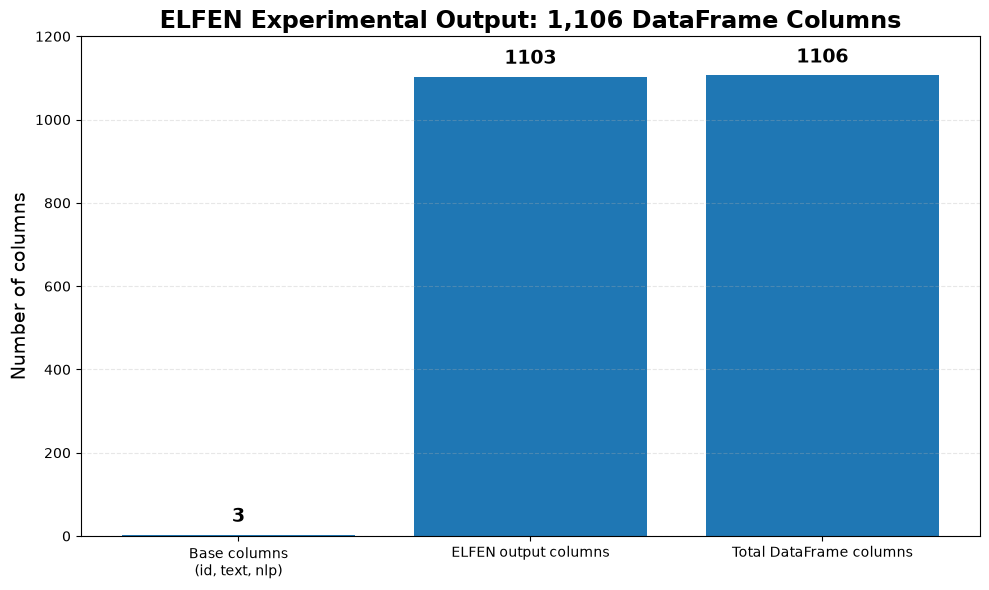

In [ ]:
import matplotlib.pyplot as plt

# Your actual ELFEN experimental output
total_columns = 1106
base_columns = 3
output_columns = 1103

labels = [
    "Base columns\n(id, text, nlp)",
    "ELFEN output columns",
    "Total DataFrame columns"
]

values = [
    base_columns,
    output_columns,
    total_columns
]

plt.figure(figsize=(10, 6))

bars = plt.bar(labels, values)

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 20,
        str(value),
        ha="center",
        va="bottom",
        fontsize=14,
        fontweight="bold"
    )

plt.ylabel("Number of columns", fontsize=14)
plt.title(
    "ELFEN Experimental Output: 1,106 DataFrame Columns",
    fontsize=17,
    fontweight="bold"
)

plt.ylim(0, 1200)
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()

# Save high-resolution image for poster
plt.savefig(
    "elfen_1106_features.png",
    dpi=300,
    bbox_inches="tight"
)

# Also save vector PDF for the A1 poster
plt.savefig(
    "elfen_1106_features.pdf",
    bbox_inches="tight"
)

plt.show()

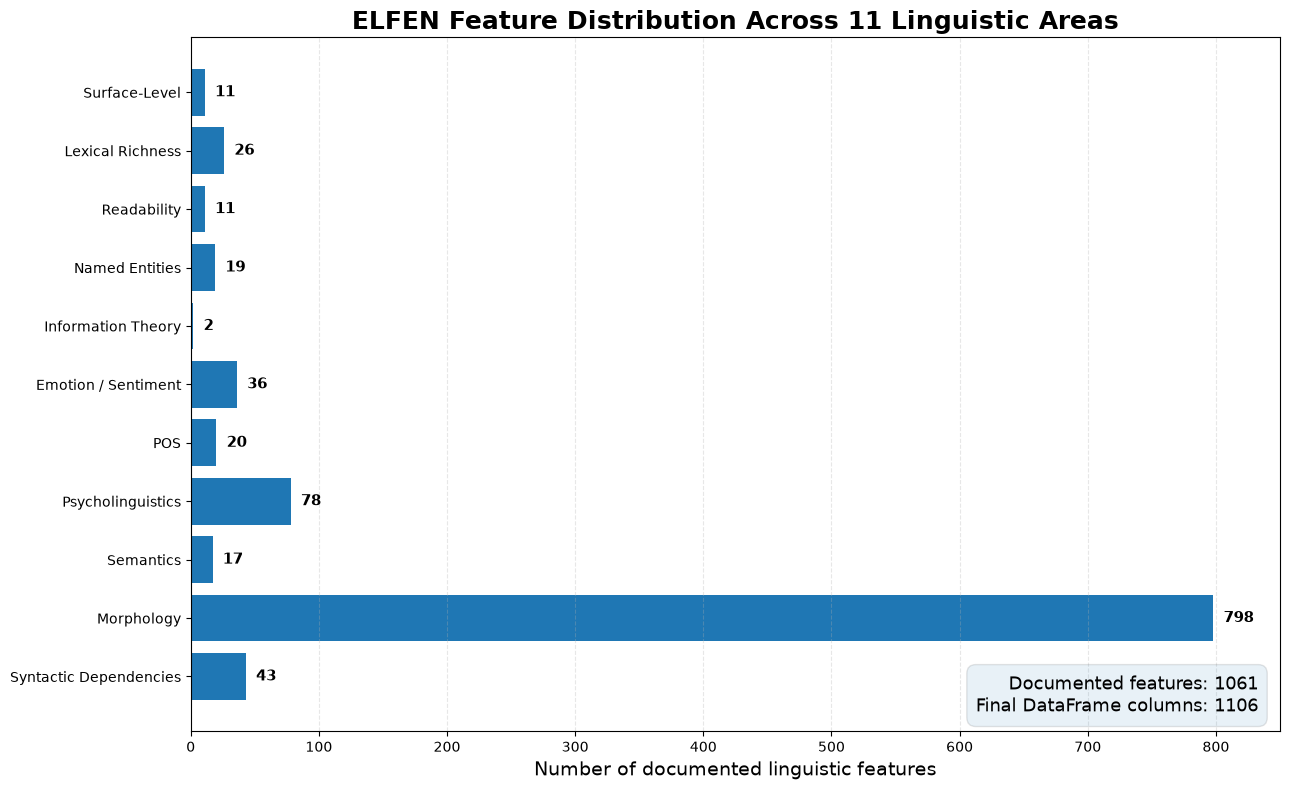

In [ ]:
import matplotlib.pyplot as plt

# ELFEN documented feature inventory
feature_areas = [
    "Surface-Level",
    "Lexical Richness",
    "Readability",
    "Named Entities",
    "Information Theory",
    "Emotion / Sentiment",
    "POS",
    "Psycholinguistics",
    "Semantics",
    "Morphology",
    "Syntactic Dependencies"
]

feature_counts = [
    11,
    26,
    11,
    19,
    2,
    36,
    20,
    78,
    17,
    798,
    43
]

# Total documented features
total_documented = sum(feature_counts)

# Actual final ELFEN DataFrame
total_dataframe_columns = 1106

# Create figure
fig, ax = plt.subplots(figsize=(13, 8))

bars = ax.barh(feature_areas, feature_counts)

# Add values to bars
for bar, value in zip(bars, feature_counts):
    ax.text(
        value + 8,
        bar.get_y() + bar.get_height() / 2,
        str(value),
        va="center",
        fontsize=11,
        fontweight="bold"
    )

# Labels
ax.set_xlabel(
    "Number of documented linguistic features",
    fontsize=14
)

ax.set_title(
    "ELFEN Feature Distribution Across 11 Linguistic Areas",
    fontsize=18,
    fontweight="bold"
)

ax.invert_yaxis()
ax.set_xlim(0, 850)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

# Add total information
ax.text(
    0.98,
    0.02,
    f"Documented features: {total_documented}\n"
    f"Final DataFrame columns: {total_dataframe_columns}",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=13,
    bbox=dict(boxstyle="round,pad=0.5", alpha=0.1)
)

plt.tight_layout()

# High-resolution image for poster
plt.savefig(
    "elfen_11_feature_areas_1106_output.png",
    dpi=300,
    bbox_inches="tight"
)

# Vector version for poster
plt.savefig(
    "elfen_11_feature_areas_1106_output.pdf",
    bbox_inches="tight"
)

plt.show()

In [ ]:
%whos

Variable                  Type            Data/Info
---------------------------------------------------
ax                        Axes            Axes(0.150556,0.0795139;0.837906x0.867569)
bar                       Rectangle       Rectangle(xy=(0, 9.6), wi<...>=43, height=0.8, angle=0)
bars                      BarContainer    <BarContainer object of 11 artists>
base_columns              int             3
feature_areas             list            n=11
feature_counts            list            n=11
fig                       Figure          Figure(1300x800)
labels                    list            n=3
np                        module          <module 'numpy' from 'c:\<...>ges\\numpy\\__init__.py'>
output_columns            int             1103
plt                       module          <module 'matplotlib.pyplo<...>\\matplotlib\\pyplot.py'>
total_columns             int             1106
total_dataframe_columns   int             1106
total_documented          int             1061
value   

Flesch Reading Ease Statistics
--------------------------------
Number of sentences : 1000
Mean                : -813.20
Median              : -731.88
Standard deviation  : 520.37
Minimum             : -3557.18
Maximum             : -51.02


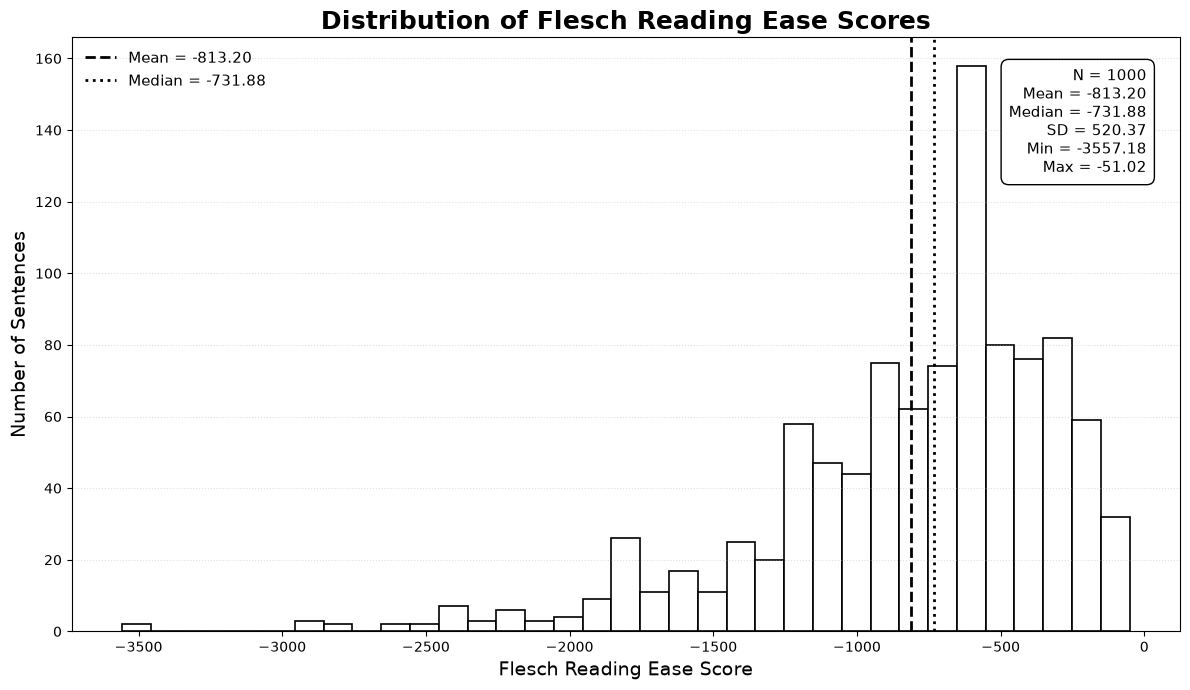

In [37]:
import numpy as np
import matplotlib.pyplot as plt

# Get Flesch Reading Ease values directly from ELFEN output
scores = (
    extractor.data
    .select("flesch_reading_ease")
    .to_series()
    .to_numpy()
)

# Remove missing or infinite values
scores = scores[np.isfinite(scores)]

# Calculate statistics
mean_score = np.mean(scores)
median_score = np.median(scores)
std_score = np.std(scores, ddof=1)
min_score = np.min(scores)
max_score = np.max(scores)

print("Flesch Reading Ease Statistics")
print("--------------------------------")
print(f"Number of sentences : {len(scores)}")
print(f"Mean                : {mean_score:.2f}")
print(f"Median              : {median_score:.2f}")
print(f"Standard deviation  : {std_score:.2f}")
print(f"Minimum             : {min_score:.2f}")
print(f"Maximum             : {max_score:.2f}")


# -----------------------------
# Create histogram
# -----------------------------

fig, ax = plt.subplots(figsize=(12, 7))

ax.hist(
    scores,
    bins=35,
    color="white",
    edgecolor="black",
    linewidth=1.2
)

# Mean line
ax.axvline(
    mean_score,
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_score:.2f}"
)

# Median line
ax.axvline(
    median_score,
    color="black",
    linestyle=":",
    linewidth=2,
    label=f"Median = {median_score:.2f}"
)

# Labels
ax.set_title(
    "Distribution of Flesch Reading Ease Scores",
    fontsize=18,
    fontweight="bold"
)

ax.set_xlabel(
    "Flesch Reading Ease Score",
    fontsize=14
)

ax.set_ylabel(
    "Number of Sentences",
    fontsize=14
)

# Statistics box
stats_text = (
    f"N = {len(scores)}\n"
    f"Mean = {mean_score:.2f}\n"
    f"Median = {median_score:.2f}\n"
    f"SD = {std_score:.2f}\n"
    f"Min = {min_score:.2f}\n"
    f"Max = {max_score:.2f}"
)

ax.text(
    0.97,
    0.95,
    stats_text,
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=11,
    bbox=dict(
        facecolor="white",
        edgecolor="black",
        boxstyle="round,pad=0.5"
    )
)

ax.legend(
    loc="upper left",
    frameon=False,
    fontsize=11
)

ax.grid(
    axis="y",
    linestyle=":",
    alpha=0.4
)

plt.tight_layout()

# Save high-resolution graph
plt.savefig(
    "flesch_reading_ease_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

# Save vector version for poster
plt.savefig(
    "flesch_reading_ease_distribution.pdf",
    bbox_inches="tight"
)

plt.show()